# Setup Environment

In [1]:
# Import libraries

# Standard libraries
from pathlib import Path

# Data manipulation and visualization libraries
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

## Models
import sklearn 
from sklearn import set_config
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer


# Saving and loading models
import joblib

print(f"NumPy version: {np.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"seaborn version: {sns.__version__}")
print(f"Scikit-Learn version: {sklearn.__version__}")

NumPy version: 2.5.1
pandas version: 3.0.3
matplotlib version: 3.11.0
seaborn version: 0.13.2
Scikit-Learn version: 1.9.0


In [2]:
# Create image and model directories if they don't exist

eda_plots_dir             = Path("plots/EDA")
model_selection_plots_dir = Path("plots/Model_Selection")
evaluation_plots_dir      = Path("plots/Evaluation")
features_plots_dir        = Path("plots/Features")
models_dir                = Path("models")

eda_plots_dir.mkdir(parents=True, exist_ok=True)
model_selection_plots_dir.mkdir(parents=True, exist_ok=True)
evaluation_plots_dir.mkdir(parents=True, exist_ok=True)
features_plots_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)

# Data Loading and Exploratory Data Analysis (EDA)

In [3]:
# Load train set and validation set

train_df = pd.read_csv(filepath_or_buffer="./data/Train.csv",
                       parse_dates=["saledate"],
                       low_memory=False).sort_values(by="saledate", ascending=True)

valid_df = pd.read_csv(filepath_or_buffer="./data/Valid.csv",
                       parse_dates=["saledate"])

valid_solution = pd.read_csv(filepath_or_buffer="./data/ValidSolution.csv")
valid_df["SalePrice"] = valid_df["SalesID"].map(valid_solution.set_index("SalesID")["SalePrice"])
valid_df = valid_df.sort_values("saledate", ascending=True).reset_index(drop=True)

print(f"[INFO] Number of samples in training DataFrame: {len(train_df)}")
print(f"[INFO] Number of samples in validation DataFrame: {len(valid_df)}")

[INFO] Number of samples in training DataFrame: 401125
[INFO] Number of samples in validation DataFrame: 11573


In [4]:
# Feature Engineering: Add date columns

def add_datetime_features_to_df(df, date_column="saledate"):
    # Add datetime parameters for saledate
    df["saleYear"] = df[date_column].dt.year
    df["saleMonth"] = df[date_column].dt.month
    df["saleDay"] = df[date_column].dt.day
    df["saleDayofweek"] = df[date_column].dt.dayofweek
    df["saleDayofyear"] = df[date_column].dt.dayofyear

    # Drop original saledate column
    df.drop("saledate", axis=1, inplace=True)

    return df

train_df = add_datetime_features_to_df(df=train_df)
valid_df = add_datetime_features_to_df(df=valid_df)
train_df.iloc[:, -5:].sample(5)

,saleYear,saleMonth,saleDay,saleDayofweek,saleDayofyear
367932,2011,6,16,3,167
104678,2002,6,4,1,155
24401,2004,8,26,3,239
253902,2001,10,16,1,289
250104,2007,11,3,5,307


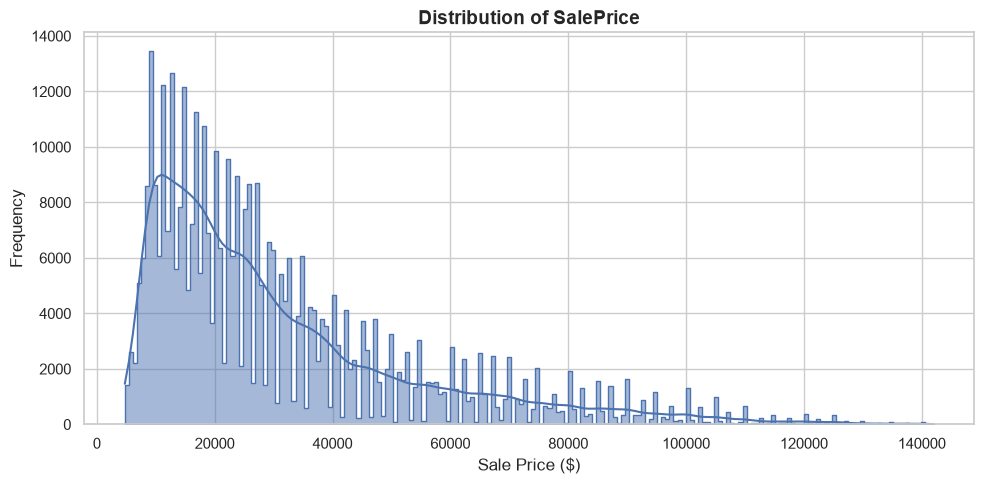

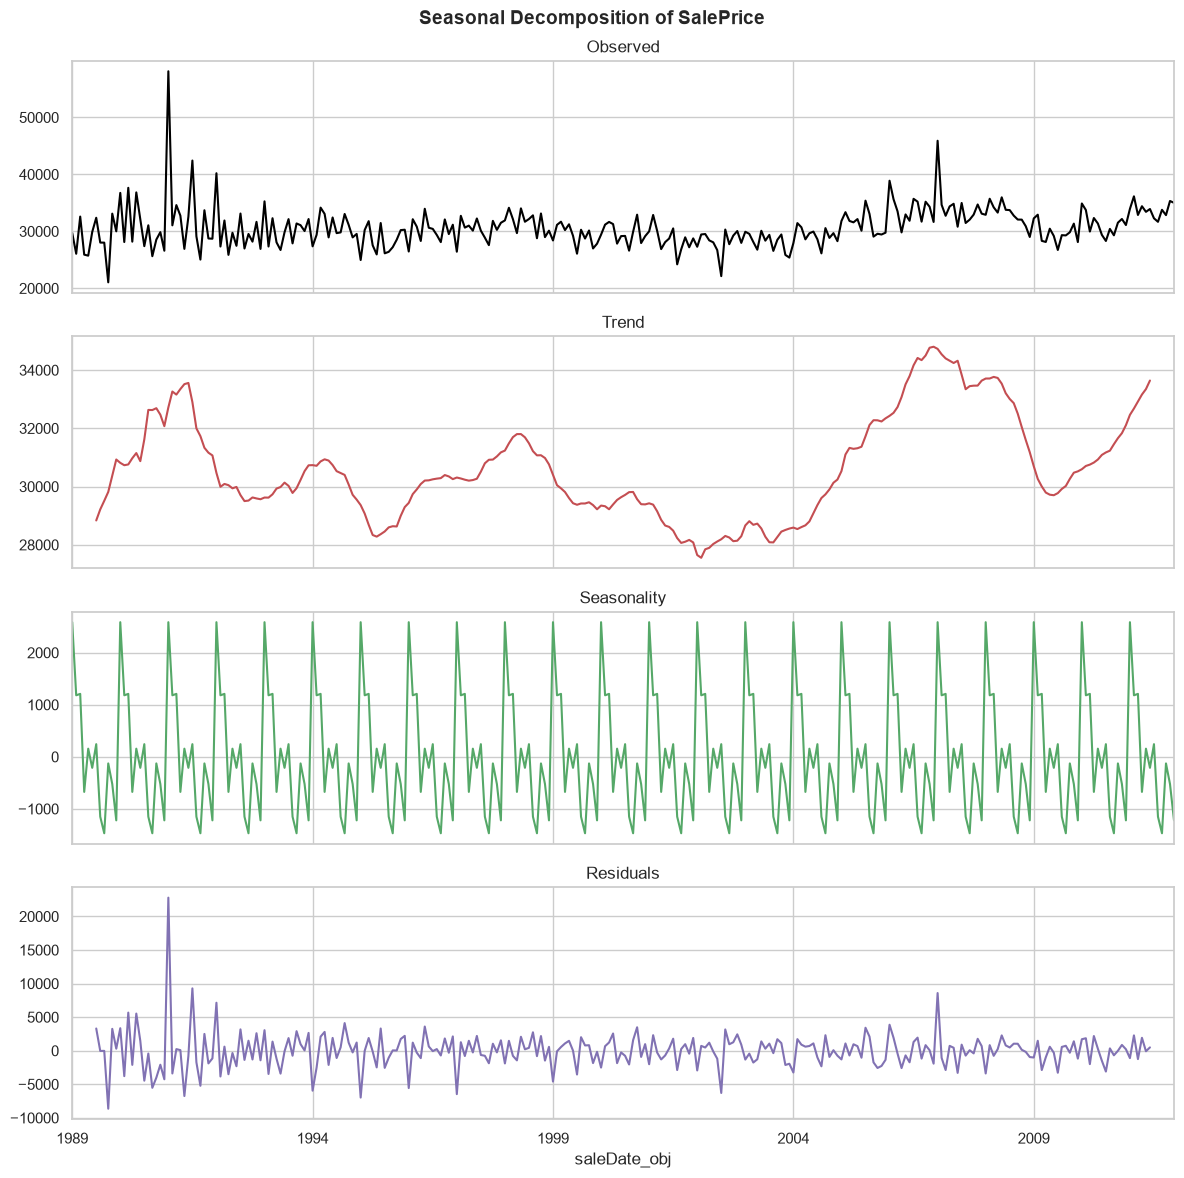

In [7]:
# EDA: Distribution of SalePrice and Seasonal Decomposition

plot_df = train_df.copy()

# Theme 
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# 1. Price Distribution Plot
plt.figure(figsize=(10, 5))
sns.histplot(plot_df["SalePrice"], kde=True, color="#4c72b0", element="step")
plt.title("Distribution of SalePrice", fontsize=14, fontweight='bold')
plt.xlabel("Sale Price ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(eda_plots_dir / "01_saleprice_distribution.png", dpi=300)  # Save the figure
plt.show()

# 2. Seasonal Decomposition Plot
# Calculate the average SalePrice for each month
plot_df["saleDate_obj"] = pd.to_datetime(
    plot_df["saleYear"].astype(str) + "-" + 
    plot_df["saleMonth"].astype(str) + "-01"
)

monthly_prices = plot_df.groupby("saleDate_obj")["SalePrice"].mean()
monthly_prices = monthly_prices.asfreq('MS')
decomposition = seasonal_decompose(monthly_prices, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)
fig.suptitle("Seasonal Decomposition of SalePrice", fontsize=14, fontweight='bold')

decomposition.observed.plot(ax=axes[0], color='black')
axes[0].set_title('Observed', fontsize=12)

decomposition.trend.plot(ax=axes[1], color='#c44e52')
axes[1].set_title('Trend', fontsize=12)

decomposition.seasonal.plot(ax=axes[2], color='#55a868')
axes[2].set_title('Seasonality', fontsize=12)

decomposition.resid.plot(ax=axes[3], color='#8172b3')
axes[3].set_title('Residuals', fontsize=12)

plt.tight_layout()  
plt.savefig(eda_plots_dir / "02_saleprice_seasonal_decomposition.png", dpi=300)  # Save the figure
plt.show()

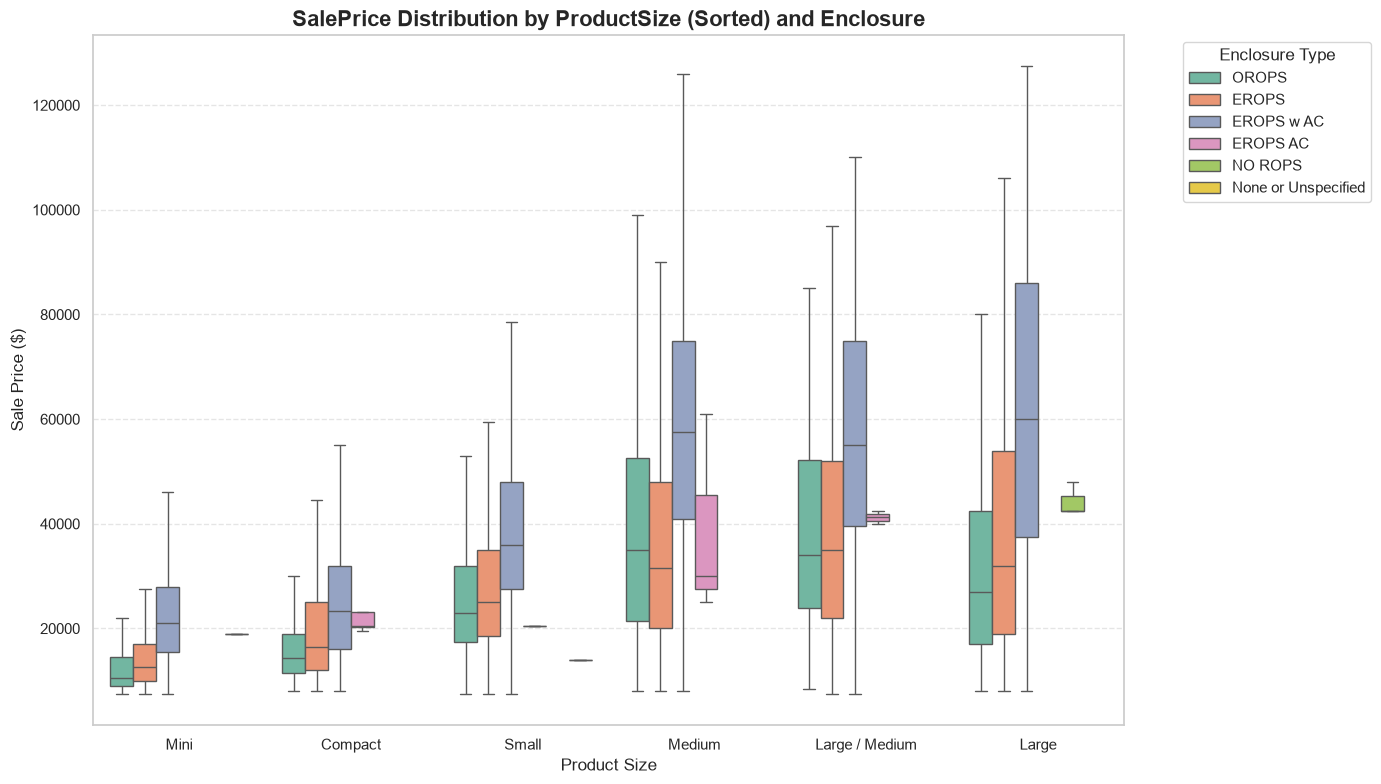

In [8]:
# EDA: SalePrice Distribution by ProductSize and Enclosure

# Define the order of ProductSize categories for better visualization
size_order = ["Mini", "Compact", "Small", "Medium", "Large / Medium", "Large"]
plot_df["ProductSize"] = pd.Categorical(
    plot_df["ProductSize"], 
    categories=size_order, 
    ordered=True
)

# Create a boxplot to visualize SalePrice distribution by ProductSize and Enclosure
plt.figure(figsize=(14, 8))
sns.boxplot(
    data=plot_df,
    x="ProductSize",
    y="SalePrice",
    hue="Enclosure",
    palette="Set2",
    showfliers=False
)

plt.title("SalePrice Distribution by ProductSize (Sorted) and Enclosure", fontsize=16, fontweight='bold')
plt.xlabel("Product Size", fontsize=12)
plt.ylabel("Sale Price ($)", fontsize=12)
plt.legend(title='Enclosure Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(eda_plots_dir / "03_EDA_saleprice_by_productsize_enclosure.png", dpi=300)  # Save the figure
plt.show()

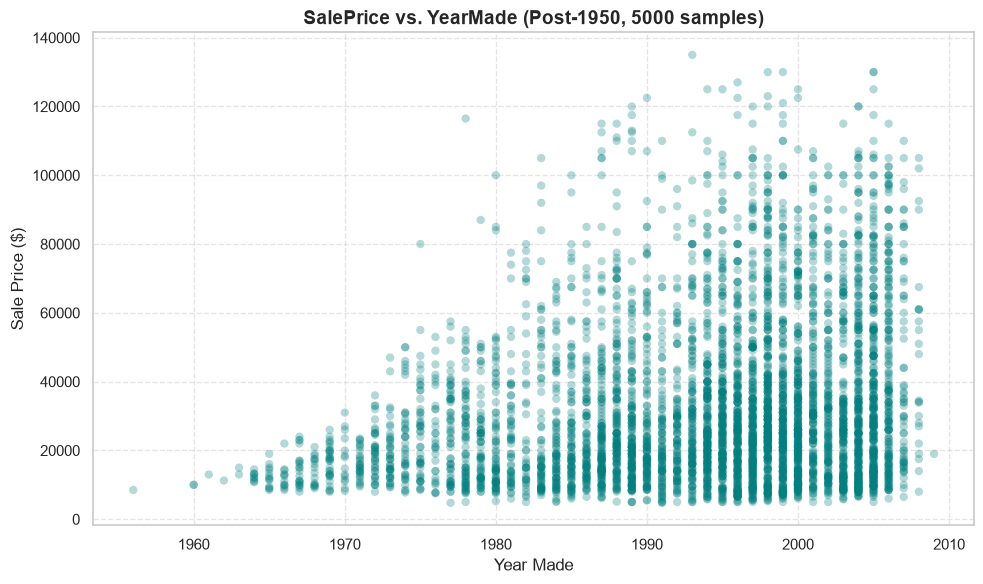

In [9]:
# EDA: SalePrice vs. YearMade (Scatter Plot)
plt.figure(figsize=(10, 6))


plot_df = plot_df[plot_df["YearMade"] > 1950].sample(5000, random_state=42)

plt.scatter(plot_df["YearMade"], plot_df["SalePrice"], 
            alpha=0.3, c="teal", edgecolors="none")

plt.title("SalePrice vs. YearMade (Post-1950, 5000 samples)", fontsize=14, fontweight='bold')
plt.xlabel("Year Made")
plt.ylabel("Sale Price ($)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(eda_plots_dir / "04_EDA_saleprice_vs_yearmade.png", dpi=300)  # Save the figure
plt.show()

# Encoding Categorical Features

In [10]:
# Split training and validation data into features and labels

X_train = train_df.drop("SalePrice", axis=1).copy()
y_train = train_df["SalePrice"].copy()

X_valid = valid_df.drop("SalePrice", axis=1).copy()
y_valid = valid_df["SalePrice"].copy()


In [15]:
# Identify categorical and numerical features

time_cols = ['saleYear', 'saleMonth', 'saleDay', 'saleDayofweek', 'saleDayofyear']

for col in time_cols:
    X_train[col] = X_train[col].astype(int)
    X_valid[col] = X_valid[col].astype(int)

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    exclude=["int64", "float64"]
).columns.tolist()

print(f"[INFO] Number of numerical features: {len(numerical_features)}")
print(f"[INFO] Numerical features: {numerical_features}")
print(f"[INFO] Number of categorical features: {len(categorical_features)}")
print(f"[INFO] Categorical features: {categorical_features}")

[INFO] Number of numerical features: 12
[INFO] Numerical features: ['SalesID', 'MachineID', 'ModelID', 'datasource', 'auctioneerID', 'YearMade', 'MachineHoursCurrentMeter', 'saleYear', 'saleMonth', 'saleDay', 'saleDayofweek', 'saleDayofyear']
[INFO] Number of categorical features: 44
[INFO] Categorical features: ['UsageBand', 'fiModelDesc', 'fiBaseModel', 'fiSecondaryDesc', 'fiModelSeries', 'fiModelDescriptor', 'ProductSize', 'fiProductClassDesc', 'state', 'ProductGroup', 'ProductGroupDesc', 'Drive_System', 'Enclosure', 'Forks', 'Pad_Type', 'Ride_Control', 'Stick', 'Transmission', 'Turbocharged', 'Blade_Extension', 'Blade_Width', 'Enclosure_Type', 'Engine_Horsepower', 'Hydraulics', 'Pushblock', 'Ripper', 'Scarifier', 'Tip_Control', 'Tire_Size', 'Coupler', 'Coupler_System', 'Grouser_Tracks', 'Hydraulics_Flow', 'Track_Type', 'Undercarriage_Pad_Width', 'Stick_Length', 'Thumb', 'Pattern_Changer', 'Grouser_Type', 'Backhoe_Mounting', 'Blade_Type', 'Travel_Controls', 'Differential_Type', 'Ste

In [18]:
# Define Preprocessing Pipeline

# 1. numerical pipeline: Fill missing values with median
num_pipeline = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median"))]
)

# 2. categorical pipeline: Fill missing values with "missing" and apply Ordinal Encoding
cat_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing"),),
        ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),),
    ]
)

# 3. Combine the pipelines into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, numerical_features),
        ("cat", cat_pipeline, categorical_features),
    ],
    remainder="drop",
)

# 4. Preprocess the training and validation data
X_train_preprocessed = preprocessor.fit_transform(X_train)  # fit on training data only to prevent data leakage
X_valid_preprocessed = preprocessor.transform(X_valid)

print(f"[INFO] X_train Shape: {X_train_preprocessed.shape}")
print(f"[INFO] X_valid Shape: {X_valid_preprocessed.shape}")

[INFO] X_train Shape: (401125, 56)
[INFO] X_valid Shape: (11573, 56)
